   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
Mean Squared Error on test set: 0.23


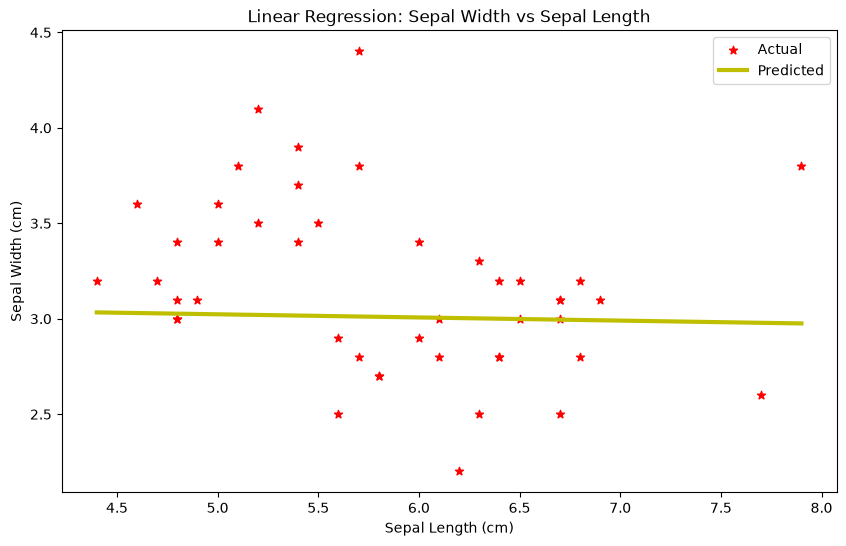

The predicted sepal width for sepal length 5 cm is 3.02 cm


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# Load Iris dataset
iris = load_iris()

# Create DataFrame
data = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)

# Add species column
data['species'] = iris.target

# Display first 5 rows
print(data.head())


# Select input and output variables
X = data[['sepal length (cm)']]
y = data['sepal width (cm)']


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)


# Create Linear Regression model
model = LinearRegression()


# Train the model
model.fit(X_train, y_train)


# Make predictions
y_pred = model.predict(X_test)


# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error on test set: {mse:.2f}")


# Plot actual and predicted values
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test,
    y_test,
    color='r',
    marker='*',
    label='Actual'
)

# Sort X_test for a proper regression line
sorted_indices = X_test['sepal length (cm)'].argsort()

plt.plot(
    X_test.iloc[sorted_indices],
    y_pred[sorted_indices],
    color='y',
    linewidth=3,
    label='Predicted'
)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Linear Regression: Sepal Width vs Sepal Length')

plt.legend()
plt.show()


# Predict for a new sample
new_sample = pd.DataFrame(
    [[5]],
    columns=['sepal length (cm)']
)

predicted_width = model.predict(new_sample)

print(
    f"The predicted sepal width for sepal length "
    f"{new_sample.iloc[0, 0]} cm is "
    f"{predicted_width[0]:.2f} cm"
)